## Imports

In [1]:
import numpy as np
import pandas as pd

from labdata.schema import Dataset, EphysRecording, SpikeSorting, UnitCount
from ephys.src.utils.io_digital_events import fetch_session_events
from ephys.src.utils.io_chipmunk_trials import fetch_trial_metadata

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegressionCV, LinearRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection, PolyCollection

%load_ext autoreload
%autoreload 2
%matplotlib widget

/Users/gabriel/lib/ephys/.venv/lib/python3.11/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-06-09 23:13:58,041][INFO]: DataJoint 0.14.9 connected to rojasbowe@churchland-data.cmojfwfr0b9t.us-west-2.rds.amazonaws.com:3306


## Preprocessing

In [2]:
subject = "GRB006"
session = "20240821_121447"
dset = Dataset & f'subject_name = "{subject}"' & f'session_name = "{session}"'

In [3]:
units = pd.DataFrame(
    (
        (
            SpikeSorting().Unit()
            & dset.fetch("subject_name", "session_name", as_dict=True)
        )
        * (UnitCount.Unit() & "unit_criteria_id = 1" & "passes = 1")
    ).fetch(
        "subject_name",
        "session_name",
        "dataset_name",
        "unit_id",
        "spike_times",
        as_dict=True,
    )
)

In [4]:
srate = float(
    (
        EphysRecording.ProbeSetting()
        & (
            SpikeSorting()
            & f'subject_name = "{subject}"'
            & f'session_name = "{session}"'
        ).proj()
    ).fetch1("sampling_rate")
)

In [5]:
aligned_events = fetch_session_events(subject, session)
trials = fetch_trial_metadata(subject, session, aligned_events)

### Create design matrix

In [6]:
valid_trials = trials[
    ((trials.with_choice == 1) & (trials.stim_category != "boundary"))
].reset_index(drop=True)

y = (valid_trials["stim_category"] == "high_rate").astype(int).to_numpy()

post_stim_window_s = 1

X = np.full((len(valid_trials), len(units)), np.nan)  # trials x units

for unit_idx, (uid, ss) in enumerate(zip(units.unit_id, units.spike_times)):
    st = ss / srate
    for trial_idx in range(len(valid_trials)):
        t = valid_trials.iloc[trial_idx]
        start = t.first_stim_ts
        stop = start + post_stim_window_s
        duration = stop - start

        n_spikes = ((st >= start) & (st < stop)).sum()
        X[trial_idx, unit_idx] = n_spikes / duration  # sp/s
assert X.shape[0] == y.shape[0]
print(f"X shape: {X.shape}\ny shape: {y.shape}")

X shape: (241, 189)
y shape: (241,)


mean integration time = 1.2677085991615311


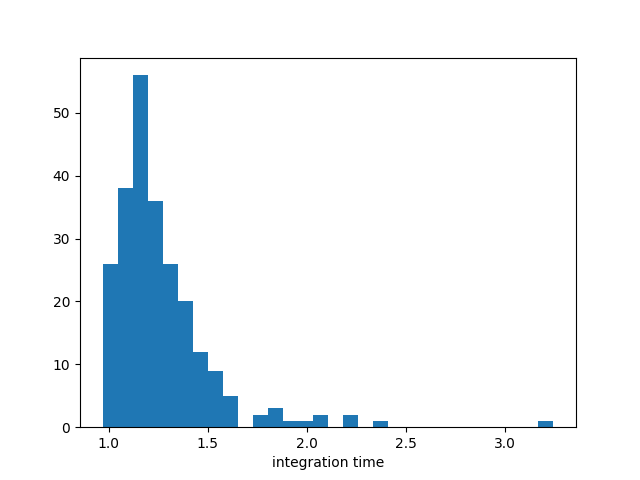

In [7]:
integration_time = valid_trials.response_ts - valid_trials.first_stim_ts

plt.hist(integration_time, 30)
plt.xlabel("integration time")
print(f"mean integration time = {np.mean(integration_time)}")

## Perform decoding

### Define decoder pipelines

In [ ]:
decoder = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(
        cv=10,
        l1_ratios=(0,),  # pyright: ignore[reportArgumentType]
        solver="lbfgs",
        scoring="accuracy",
        max_iter=1000,
        class_weight="balanced",
        fit_intercept=True,
        use_legacy_attributes=False,
    ),
)

### Set up cross-validator and score real models

In [9]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
scores = cross_val_score(decoder, X, y, cv=cv, scoring="accuracy")

/Users/gabriel/lib/ephys/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
/Users/gabriel/lib/ephys/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the t

### Score shuffle models

In [10]:
rng = np.random.default_rng(0)

n_shuffles = 10
shuffle_scores = []
for _ in tqdm(range(n_shuffles)):
    y_shuffle = rng.permutation(y)
    s = cross_val_score(decoder, X, y_shuffle, cv=cv, scoring="accuracy").mean()
    shuffle_scores.append(s)

shuffle_scores = np.array(shuffle_scores)

assert scores.shape[0] == shuffle_scores.shape[0]

  0%|          | 0/10 [00:00<?, ?it/s]/Users/gabriel/lib/ephys/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
/Users/gabriel/lib/ephys/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while kee

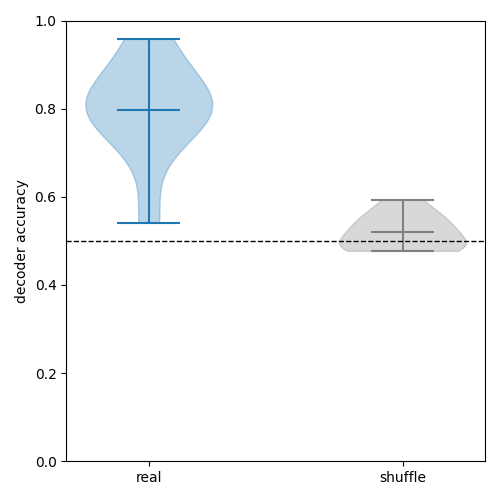

In [11]:
fig, ax = plt.subplots(1, figsize=(5, 5))

positions = [1.0, 1.5]

violin_colors = ["tab:blue", "gray"]

parts = ax.violinplot(
    [scores, shuffle_scores],
    positions=positions,
    widths=0.25,
    showmeans=True,
)
bodies = parts["bodies"]
if not isinstance(bodies, list):
    raise TypeError("expected violin bodies to be a list")

for body, color in zip(bodies, violin_colors):
    if not isinstance(body, PolyCollection):
        raise TypeError("expected violin body to be a PolyCollection")
    body.set_facecolor(color)
    body.set_edgecolor(color)

for key in ("cmeans", "cmaxes", "cmins", "cbars", "cmedians"):
    lines = parts.get(key)
    if isinstance(lines, LineCollection):
        lines.set_colors(violin_colors)

ax.set_xticks(positions)
ax.set_xticklabels(["real", "shuffle"])

ax.axhline(0.5, color="k", linestyle="--", linewidth=1)

ax.set_ylabel("decoder accuracy")
ax.set_ylim((0, 1))
fig.tight_layout()

In [12]:
X_choice = (
    (valid_trials["response"] == 1).astype(int).to_numpy().reshape(-1, 1)
)  # choice
y_choice = (
    X.copy()
)  # since X was neural activity in the decoder, y is now neural activity

assert X_choice.shape[0] == y_choice.shape[0]

choice_encoder = make_pipeline(StandardScaler(), LinearRegression())

choice_encoder.fit(X_choice, y_choice)  # fitting on all trials for now
y_choice_pred = choice_encoder.predict(
    X_choice
)  # there will be some leakage here, but it's ok
y_choice_resid = y_choice - y_choice_pred

choice_score = choice_encoder.score(X_choice, y_choice)
print(f"choice encoder R^2 across units: {choice_score:.3f}")

choice encoder R^2 across units: 0.059


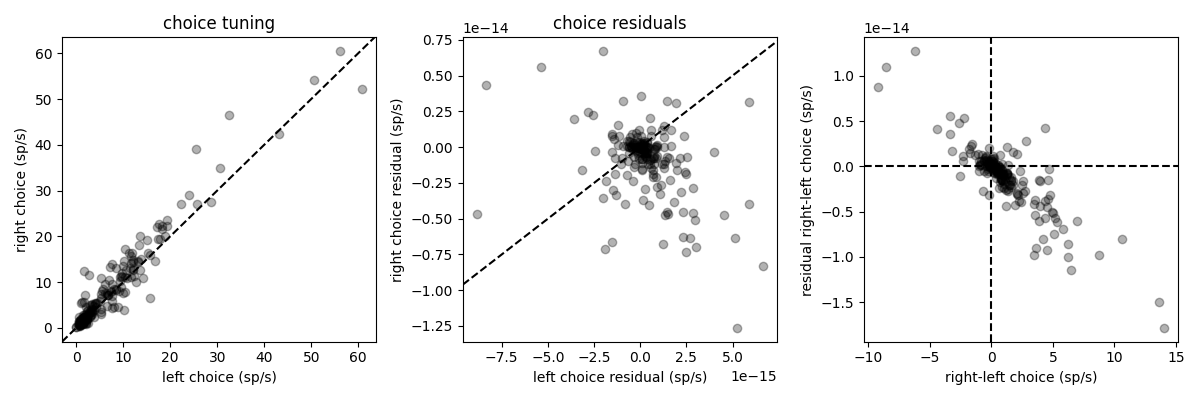

In [13]:
left_choice = X_choice[:, 0] == 0
right_choice = X_choice[:, 0] == 1

raw_left = y_choice[left_choice].mean(axis=0)
raw_right = y_choice[right_choice].mean(axis=0)

resid_left = y_choice_resid[left_choice].mean(axis=0)
resid_right = y_choice_resid[right_choice].mean(axis=0)

raw_delta = raw_right - raw_left
resid_delta = resid_right - resid_left

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].scatter(raw_left, raw_right, color="k", alpha=0.3)
axs[0].axline((0, 0), slope=1, color="black", linestyle="--")
axs[0].set_xlabel("left choice (sp/s)")
axs[0].set_ylabel("right choice (sp/s)")
axs[0].set_title("choice tuning")

axs[1].scatter(resid_left, resid_right, color="k", alpha=0.3)
axs[1].axline((0, 0), slope=1, color="black", linestyle="--")
axs[1].set_xlabel("left choice residual (sp/s)")
axs[1].set_ylabel("right choice residual (sp/s)")
axs[1].set_title("choice residuals")

axs[2].scatter(raw_delta, resid_delta, color="k", alpha=0.3)
axs[2].axhline(0, color="black", linestyle="--")
axs[2].axline((0, 0), slope=1, color="black", linestyle="--")
axs[2].set_xlabel("right-left choice (sp/s)")
axs[2].set_ylabel("residual right-left choice (sp/s)")

fig.tight_layout()

Text(0.5, 1.0, 'trial-by-trial variance remains after choice regression')

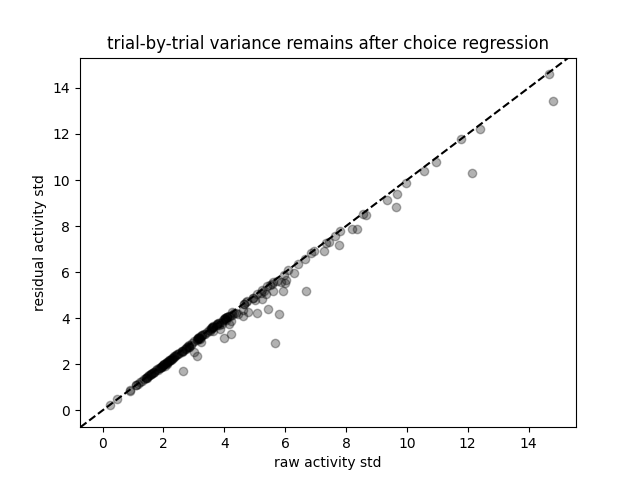

In [14]:
raw_std = y_choice.std(axis=0)
resid_std = y_choice_resid.std(axis=0)

fig, ax = plt.subplots(1)
ax.scatter(raw_std, resid_std, color="k", alpha=0.3)
ax.axline((0, 0), slope=1, color="black", linestyle="--")
ax.set_xlabel("raw activity std")
ax.set_ylabel("residual activity std")
ax.set_title("trial-by-trial variance remains after choice regression")

## Inspecting the weights

In [15]:
decoder.fit(X, y)

logreg = decoder.named_steps["logisticregressioncv"]
coefs = logreg.coef_[0]

/Users/gabriel/lib/ephys/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Text(0, 0.5, 'weights')

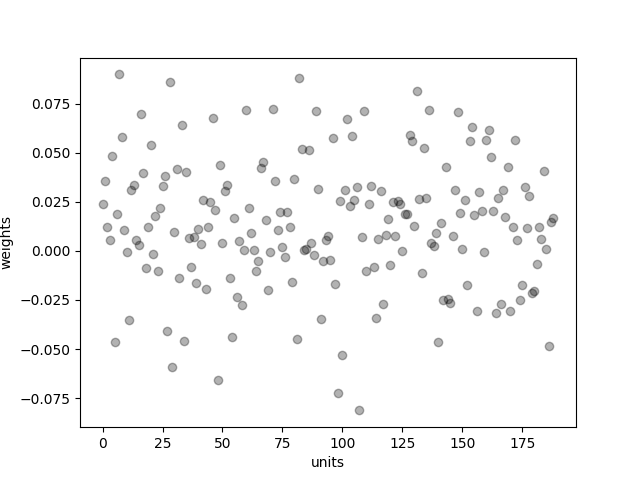

In [16]:
fig, ax = plt.subplots(1)
x = np.arange(0, len(coefs), 1)
ax.scatter(x, coefs, color="k", alpha=0.3)
ax.set_xlabel("units")
ax.set_ylabel("weights")

Text(0, 0.5, 'units')

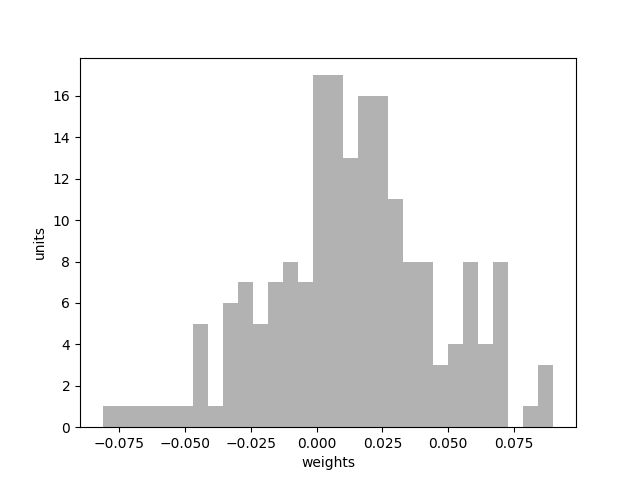

In [17]:
fig, ax = plt.subplots(1)
ax.hist(coefs, bins=30, color="k", alpha=0.3)
ax.set_xlabel("weights")
ax.set_ylabel("units")

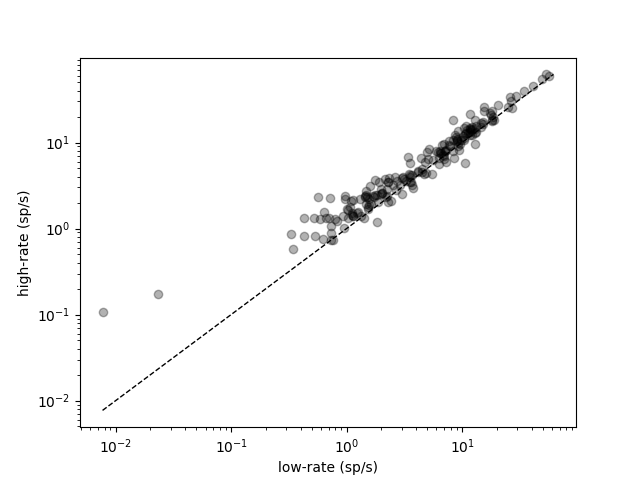

In [18]:
fig, ax = plt.subplots(1)

low_mean = X[y == 0].mean(axis=0)
high_mean = X[y == 1].mean(axis=0)

ax.scatter(low_mean, high_mean, color="k", alpha=0.3)
lim = [
    min(low_mean.min(), high_mean.min()),
    max(low_mean.max(), high_mean.max()),
]
ax.plot(lim, lim, color="k", linestyle="--", linewidth=1)

ax.set_xlabel("low-rate (sp/s)")
ax.set_ylabel("high-rate (sp/s)")
ax.set_xscale("log")
ax.set_yscale("log")

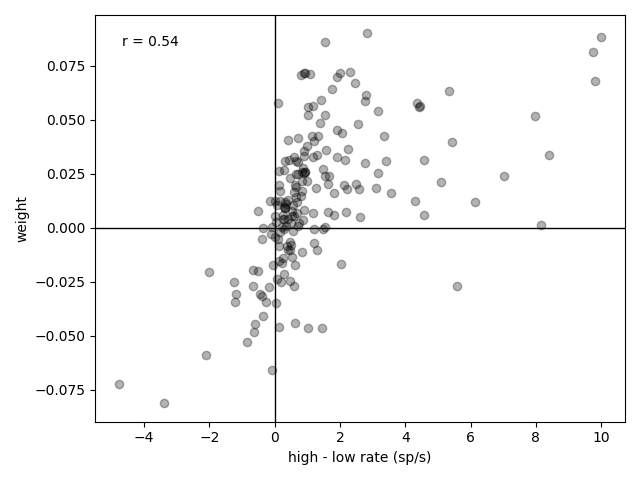

In [19]:
fig, ax = plt.subplots(1)

delta = X[y == 1].mean(axis=0) - X[y == 0].mean(axis=0)
r = np.corrcoef(delta, coefs)[0, 1]

ax.scatter(delta, coefs, color="k", alpha=0.3)
ax.axhline(0, color="k", linewidth=1)
ax.axvline(0, color="k", linewidth=1)

ax.text(
    0.05,
    0.95,
    f"r = {r:.2f}",
    transform=ax.transAxes,
    va="top",
)

ax.set_xlabel("high - low rate (sp/s)")
ax.set_ylabel("weight")
fig.tight_layout()

## Time-course decoding

In [20]:
valid_trials = trials[
    ((trials.with_choice == 1) & (trials.stim_category != "boundary"))
].reset_index(drop=True)

n_timepoints = 10
bin_edges = np.linspace(0, post_stim_window_s, n_timepoints + 1)
bin_centers = bin_edges[:-1] + np.diff(bin_edges) / 2

y_time = (valid_trials["stim_category"] == "high_rate").astype(int).to_numpy()

X_time = np.full(
    (len(valid_trials), len(units), n_timepoints), np.nan
)  # trials x units x timepoints

for unit_idx, (uid, ss) in enumerate(zip(units.unit_id, units.spike_times)):
    st = ss / srate
    for trial_idx in range(len(valid_trials)):
        t = valid_trials.iloc[trial_idx]
        bins = t.first_stim_ts + bin_edges
        durations = np.diff(bins)

        rates = []
        for i in range(len(bins) - 1):
            rate = ((st >= bins[i]) & (st < bins[i + 1])).sum() / durations[i]
            rates.append(rate)

        X_time[trial_idx, unit_idx] = rates  # sp/s

assert X_time.shape[0] == y_time.shape[0]
print(f"X shape: {X_time.shape}\ny shape: {y_time.shape}")

X shape: (241, 189, 10)
y shape: (241,)


In [21]:
real_scores = np.full((n_timepoints, cv.get_n_splits()), np.nan)

print("Scoring models...")
for time_idx in tqdm(range(n_timepoints)):
    Xt = X_time[:, :, time_idx]
    real_scores[time_idx] = cross_val_score(
        decoder,
        Xt,
        y_time,
        cv=cv,
        scoring="accuracy",
    )

shuffle_scores = np.full((n_shuffles, n_timepoints, cv.get_n_splits()), np.nan)

print("Shuffling data...")
for shuffle_idx in tqdm(range(n_shuffles)):
    y_shuff = rng.permutation(y)

    for time_idx in range(n_timepoints):
        Xt = X_time[:, :, time_idx]
        shuffle_scores[shuffle_idx, time_idx] = cross_val_score(
            decoder,
            Xt,
            y_shuff,
            cv=cv,
            scoring="accuracy",
        )

Scoring models...


  0%|          | 0/10 [00:00<?, ?it/s]/Users/gabriel/lib/ephys/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
/Users/gabriel/lib/ephys/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while kee

Shuffling data...


  0%|          | 0/10 [00:00<?, ?it/s]/Users/gabriel/lib/ephys/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
/Users/gabriel/lib/ephys/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while kee

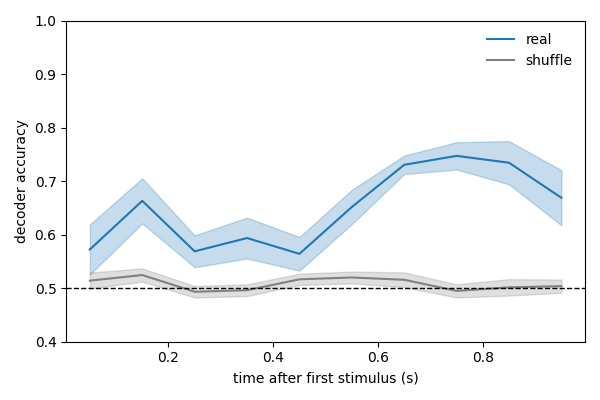

In [22]:
fig, ax = plt.subplots(1, figsize=(6, 4))

time = bin_centers

real_mean = real_scores.mean(axis=1)
real_sem = real_scores.std(axis=1, ddof=1) / np.sqrt(real_scores.shape[1])

shuffle_mean_by_run = shuffle_scores.mean(axis=2)  # shuffles x time
shuffle_mean = shuffle_mean_by_run.mean(axis=0)
shuffle_sem = shuffle_mean_by_run.std(axis=0, ddof=1) / np.sqrt(n_shuffles)

ax.plot(time, real_mean, color="tab:blue", label="real")
ax.fill_between(
    time,
    real_mean - real_sem,
    real_mean + real_sem,
    color="tab:blue",
    alpha=0.25,
)

ax.plot(time, shuffle_mean, color="0.5", label="shuffle")
ax.fill_between(
    time,
    shuffle_mean - shuffle_sem,
    shuffle_mean + shuffle_sem,
    color="0.5",
    alpha=0.25,
)

ax.axhline(0.5, color="k", linestyle="--", linewidth=1)

ax.set_xlabel("time after first stimulus (s)")
ax.set_ylabel("decoder accuracy")
ax.set_ylim((0.4, 1))
ax.legend(frameon=False)
fig.tight_layout()